In [26]:
# Move to project directory
import os
os.chdir("/home/mdarif/MLOPS/wine-quality-prediction-system")
print(os.getcwd())

/home/mdarif/MLOPS/wine-quality-prediction-system


# Table of Content

**1. Introduction**

**2. Data Loading and Initial Exploration**
- 2.1 Importing Libraries
- 2.2 Loading Dataset
- 2.3 Initial Data Inspection
- 2.4 Missing Value Analysis
- 2.5 Duplicate Analysis
- 2.6 Duplicate Removal
- 2.7 Data Manipulation

**3. Exploratory Data Analysis (EDA)**
- 3.1 Overview
- 3.2 Target (Quality) Distribution
- 3.3 Feature Distributions
- 3.4 Feature Relationships with Quality
- 3.5 Correlation Matrix
- 3.6 EDA Conclusions

## 1. Introduction

Wine quality is influenced by different chemical properties such as acidity, sugar, sulphur dioxide, and alcohol content. The dataset used in this project is the red wine quality dataset from Cortez et al. (2009). Each wine sample has a quality score between 3 and 8, based on sensory evaluation by wine tasters.

The dataset contains 11 physicochemical features and all of them are numeric so there is no need for categorical encoding. During the initial analysis, we will also check for duplicate records, missing values, and unusual distributions in the features.

The main goal of this EDA is to understand the dataset identify important patterns and relationships between the chemical properties and wine quality and prepare the data for the modeling stage.


## 2. Data Loading and Initial Exploration

#### Feature Descriptions:

- **fixed acidity** - Amount of non-volatile acids in the wine.
- **volatile acidity** - Amount of acetic acid in the wine, which can affect the wine's taste and quality.
- **citric acid** - Amount of citric acid in the wine, which can contribute to freshness and flavor.
- **residual sugar** - Amount of sugar remaining in the wine after fermentation.
- **chlorides** - Amount of salt present in the wine.
- **free sulfur dioxide** - Amount of free sulfur dioxide, which helps prevent microbial growth and oxidation.
- **total sulfur dioxide** - Total amount of sulfur dioxide present in the wine.
- **density** - Density of the wine, which is related to its alcohol and sugar content.
- **pH** - Measure of the acidity or alkalinity of the wine.
- **sulphates** - Amount of sulphates in the wine, which can contribute to preservation and flavor.
- **alcohol** - Percentage of alcohol in the wine.
- **quality** - Target feature: representing the quality score of the wine.

### 2.2 Importing Libraries

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi

In [28]:
# Load environment variables
load_dotenv()

True

In [29]:
# Download dataset from kaggle
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_api_token = os.getenv("KAGGLE_API_TOKEN")

if not kaggle_username or not kaggle_api_token:
    raise ValueError("KAGGLE_USERNAME and KAGGLE_API_TOKEN must be set.")

api = KaggleApi()
api.authenticate()

dataset = "uciml/red-wine-quality-cortez-et-al-2009"
download_dir = "/tmp/wine-quality"
os.makedirs(download_dir, exist_ok=True)

api.dataset_download_files(
    dataset,
    path=download_dir,
    unzip=True
)

file_path = os.path.join(
    download_dir,
    "winequality-red.csv"
)
print(file_path)

Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
/tmp/wine-quality/winequality-red.csv


### 2.3 Initial Data Inspection

In [30]:
# Load the dataset and display the first five rows
df = pd.read_csv(file_path)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [31]:
# Display the last five rows
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [32]:
# Display dataset columns
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [33]:
# Display dataset shape
df.shape

(1599, 12)

In [34]:
# Check the missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Obsevation

No missing values here this dataset is small and clean by nature. Confirmed by the all-zero counts above.

In [35]:
# Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Duplicate rows: {duplicate_count}")
duplicate_rows.head()

Duplicate rows: 240


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
22,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5


### Observation

This dataset is known to carry a fair number of exact duplicate rows
different wine samples that happened to land on identical measurements
(down to the same quality score). 240 duplicate rows here, worth checking
whether any of them actually conflict before dropping.

In [36]:
# Check duplicate features for different target values
feature_columns = df.columns.drop("quality")

duplicate_features = (
    df[df.duplicated(subset=feature_columns, keep=False)]
    .sort_values(by=list(feature_columns))
)

target_counts = (
    duplicate_features.groupby(list(feature_columns))["quality"].nunique()
)

conflicting_duplicates = target_counts[target_counts > 1]
print(f"Conflicting duplicate groups: {len(conflicting_duplicates)}")

Conflicting duplicate groups: 0


### 2.4 Removing Duplicates

Zero conflicting duplicate groups none of the 240 duplicate rows disagree
on quality, so they're just repeated samples rather than label noise. Safe
to drop the exact duplicates: they're not adding new information, just
repeating a sample.

In [37]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (1359, 12)


In [38]:
# Descriptive statistics for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Overview 

Every feature here is numeric, so there's no categorical vs numeric split.

- **Physicochemical properties** (the 11 measured features): `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`

- **Target:** `quality`

In [39]:
# split feature column for reuse below
feature_columns = df.columns.drop("quality").tolist()
print(f"Number of features: {len(feature_columns)}")
print(feature_columns)

Number of features: 11
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 3.2 Target (Quality) Distribution

Wine quality is scored on a 0-10 scale by human tasters, but in practice
this dataset only contains scores from 3 to 8 nobody rated a wine at the
extremes.

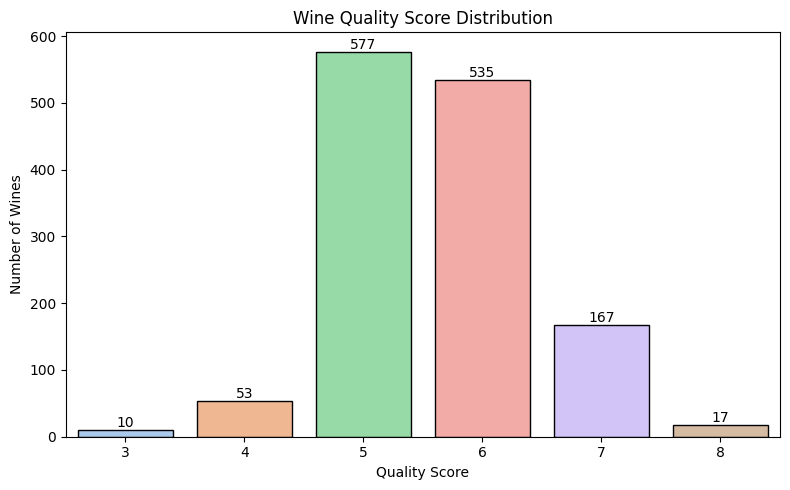

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [40]:
# Count wines at each quality score
quality_counts = df["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df,
    x="quality",
    hue="quality",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

ax.set_title("Wine Quality Score Distribution")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Number of Wines")

plt.tight_layout()
plt.show()

quality_counts

### Observation

Confirmed: quality 5 (577 wines) and 6 (535 wines) together make up 1,112
of the 1,359 samples about 82%. The extremes are barely represented: only
10 wines rated 3, and 17 rated 8. This is effectively a regression problem
with a narrow, imbalanced target a model that just predicts "5 or 6 for
everyone" will already look decent on RMSE, so RMSE/MAE numbers need to be
read with that baseline in mind rather than taken at face value.

### 3.3 Feature Distributions

Looking at how each of the 11 chemical measurements is distributed on its own, before checking any of them against quality.

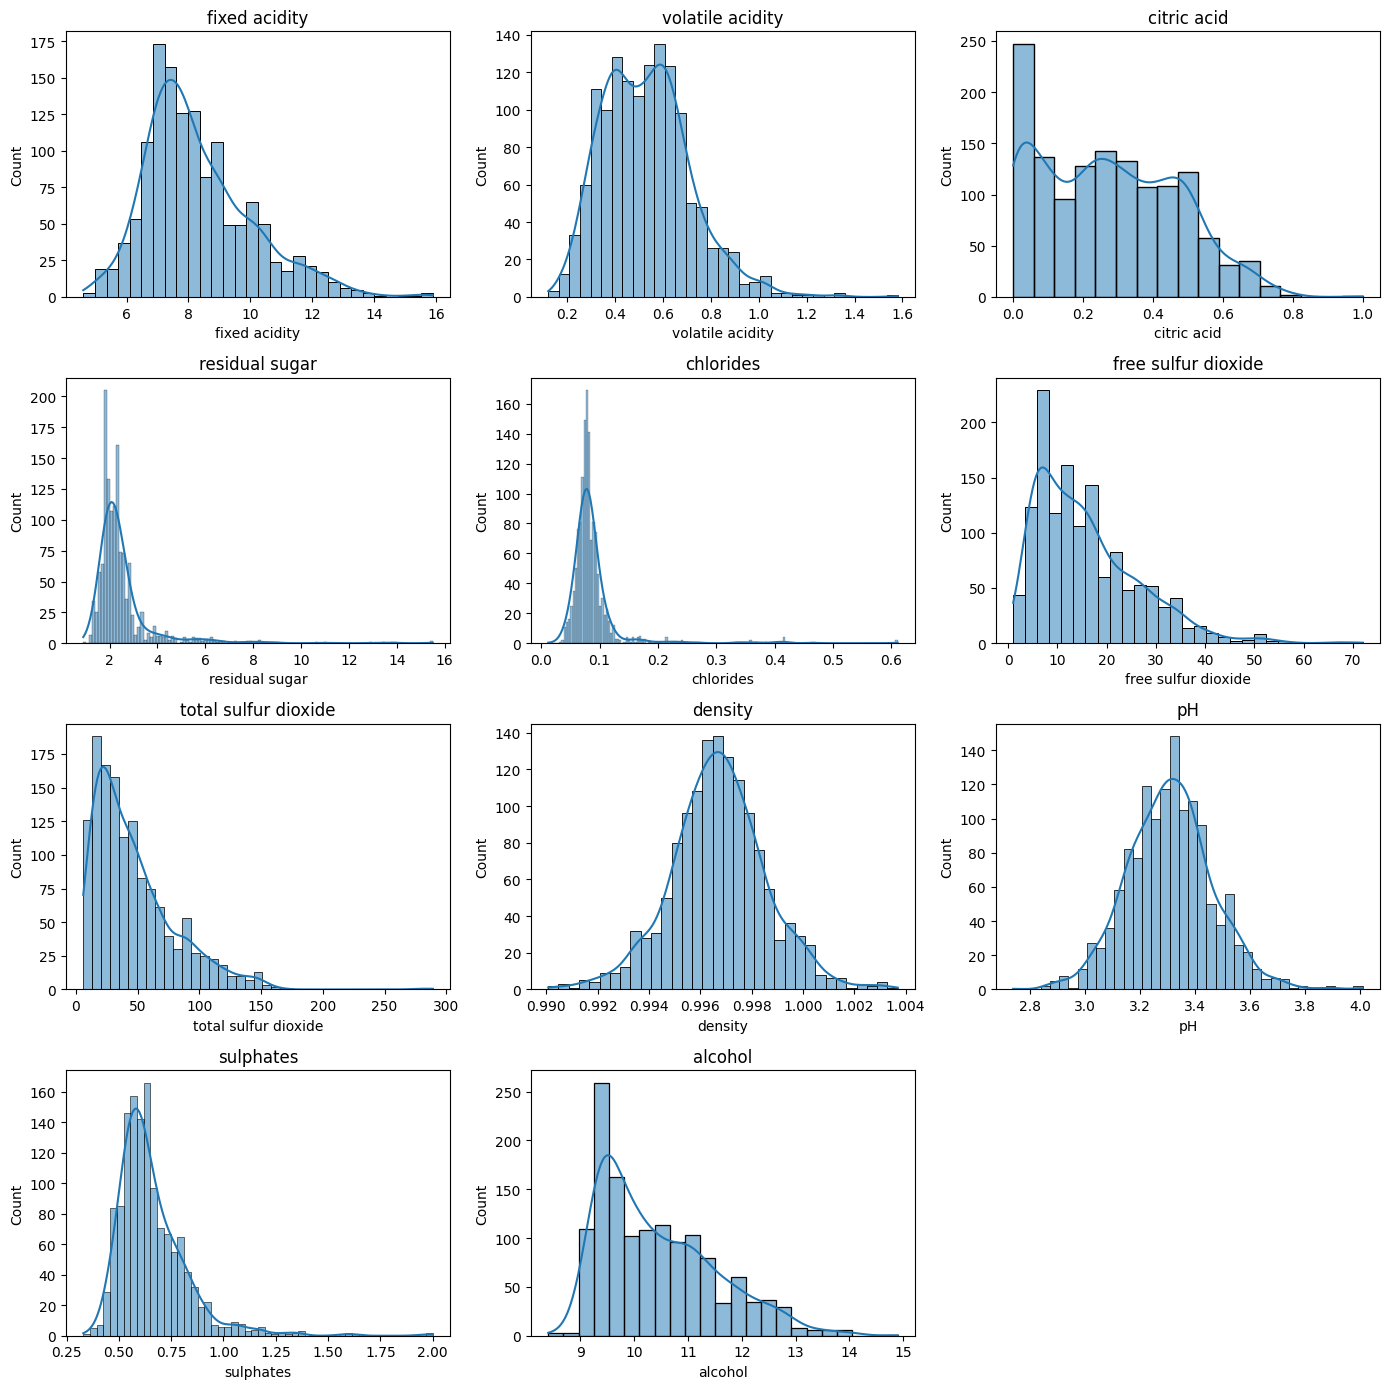

In [41]:
# Grid of histograms for all 11 features
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 14))
axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        edgecolor="black",
        ax=ax
    )
    ax.set_title(feature)

# Hide the unused 12th subplot (11 features in a 4x3 grid)
for ax in axes[len(feature_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Observation

Comparing mean vs. median from the `describe()` table above confirms the
skew directly: `residual sugar` (mean 2.52 vs. median 2.20, max 15.5),
`chlorides` (mean 0.088 vs. median 0.079, max 0.611), `free sulfur dioxide`
(mean 15.9 vs. median 14.0, max 72), and `total sulfur dioxide` (mean 46.8
vs. median 38.0, max 289) are all right-skewed each has a mean pulled
well above its median by a long tail of high values. `density` (mean
0.99671 vs. median 0.99670) and `pH` (mean 3.3098 vs. median 3.31) are
both essentially symmetric mean and median nearly identical. Skewed
features like these sometimes benefit from a log transform before
modeling, even though tree-based models won't care either way.

### 3.4 Feature Relationships with Quality

Checking a handful of features against the quality score directly starting with the ones most commonly reported as influential for this dataset: `alcohol`, `volatile acidity`, `sulphates` and `citric acid`.

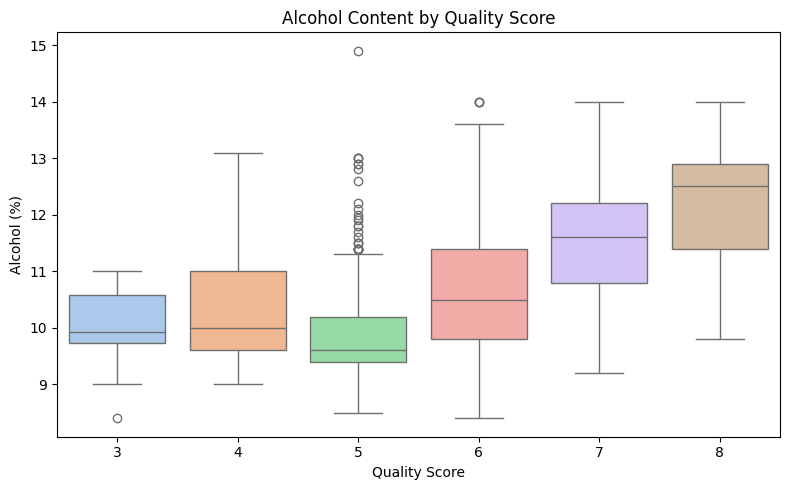

In [42]:
# Compare alcohol content across quality scores
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="quality",
    y="alcohol",
    hue="quality",
    palette="pastel",
    legend=False,
    ax=ax
)

ax.set_title("Alcohol Content by Quality Score")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Alcohol (%)")

plt.tight_layout()
plt.show()

### Observation

This is usually the strongest single relationship in this dataset
higher-quality wines tend to have noticeably higher alcohol content,
especially from quality 5 upward. Check whether that trend holds here.

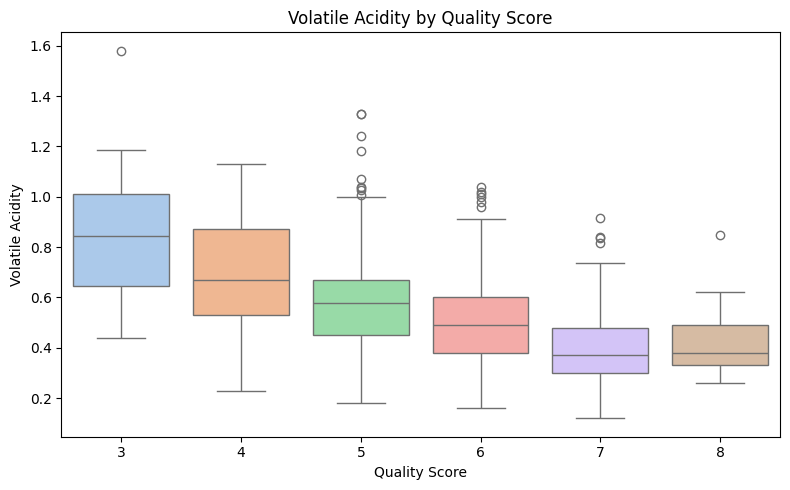

In [43]:
# Compare volatile acidity across quality scores
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="quality",
    y="volatile acidity",
    hue="quality",
    palette="pastel",
    legend=False,
    ax=ax
)

ax.set_title("Volatile Acidity by Quality Score")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Volatile Acidity")

plt.tight_layout()
plt.show()

### Observation

This one usually goes the other way volatile acidity (essentially the
"vinegar" component) tends to be higher in lower-quality wines and lower
in higher-quality ones. Makes intuitive sense: too much acetic acid is a
flaw tasters would penalize.

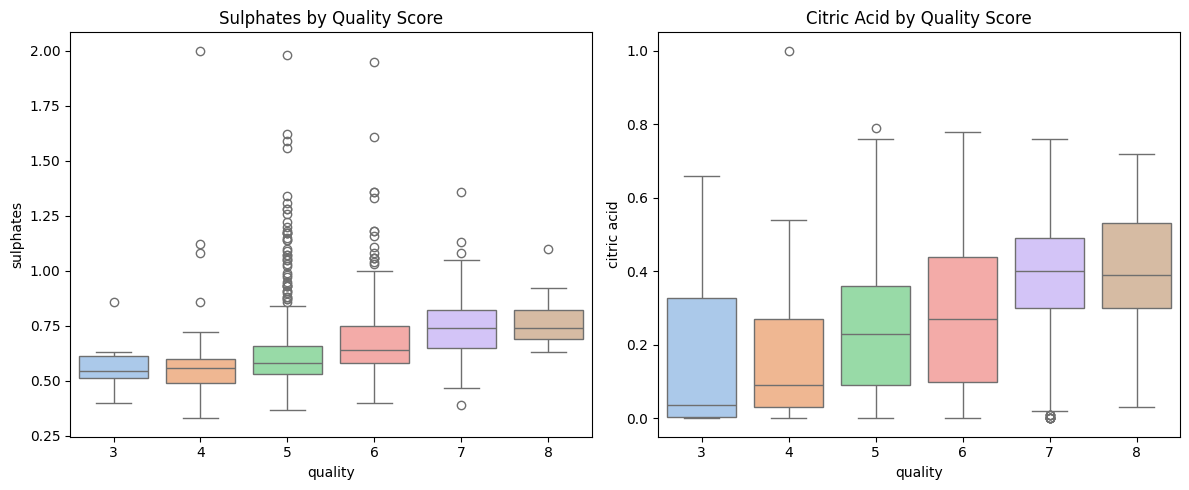

In [44]:
# Compare sulphates and citric acid across quality scores
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x="quality",
    y="sulphates",
    hue="quality",
    palette="pastel",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Sulphates by Quality Score")

sns.boxplot(
    data=df,
    x="quality",
    y="citric acid",
    hue="quality",
    palette="pastel",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Citric Acid by Quality Score")

plt.tight_layout()
plt.show()

### Observation

Both of these usually trend upward with quality too, though less sharply
than alcohol. Worth a look at whether the pattern is as clean here.

### 3.5 Correlation Matrix

Putting a number on all of the above at once how each feature correlates
with quality, and with each other.

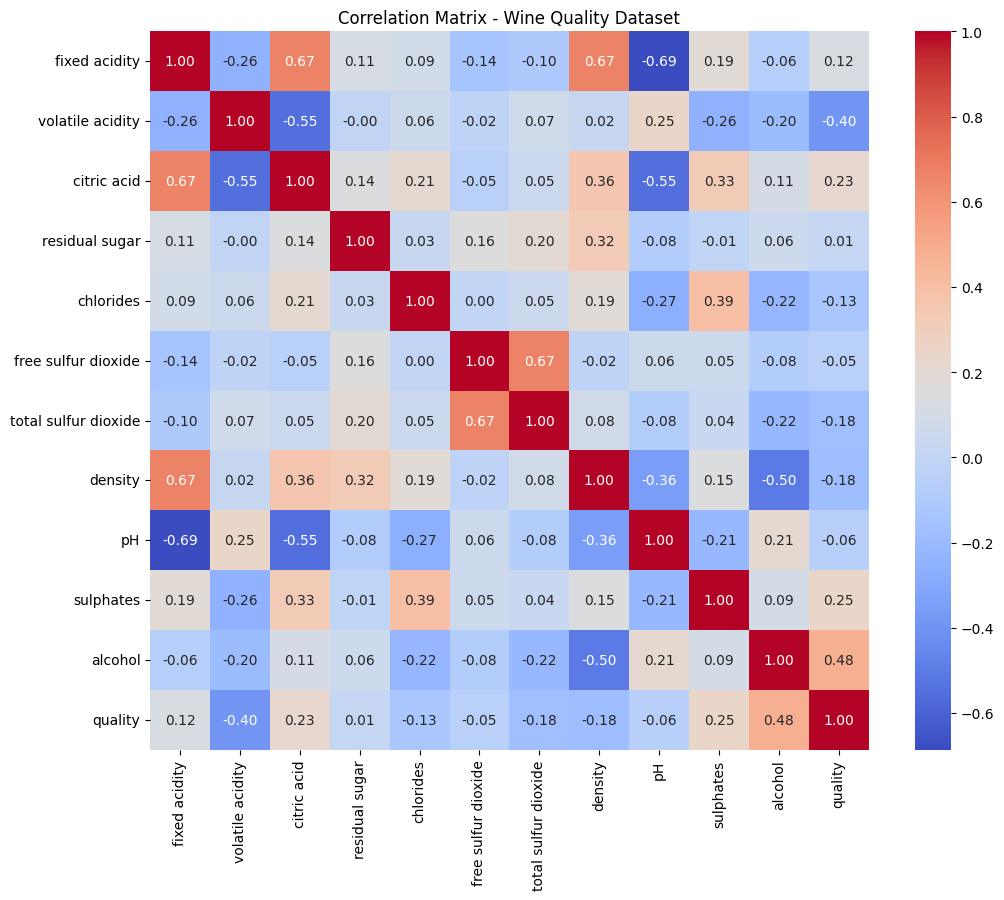

In [46]:
# Correlation matrix for all numerical features
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    ax=ax
)

ax.set_title("Correlation Matrix - Wine Quality Dataset")
plt.tight_layout()
plt.show()

In [47]:
# Correlation of each feature with quality specifically, sorted
quality_corr = corr_matrix["quality"].drop("quality").sort_values(ascending=False)
quality_corr

alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

### 3.6 EDA Conclusions

- Quality scores are heavily concentrated at 5 and 6 (about 82% of
  samples combined) a narrow, imbalanced target even though it's framed
  as regression.
- `alcohol` looks like the single most useful predictor, with a moderate
  positive relationship to quality.
- `volatile acidity` is the clearest negative predictor.
- `sulphates` and `citric acid` contribute more weakly in the positive
  direction.
- `residual sugar`, `chlorides`, `free sulfur dioxide`, and `total sulfur
  dioxide` are all right-skewed, confirmed by their mean-vs-median gap.
- No single feature correlates strongly with quality on its own a model
  will need to combine several features to do reasonably well, which is
  consistent with the moderate R2 scores seen across models in the
  Experiments notebook.
- `free sulfur dioxide` and `total sulfur dioxide` are related to each
  other by construction, worth keeping in mind for linear models.